In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
df = pd.read_csv("백화점매출정보.csv")
print(df.head())
print(df.shape)
print(df.info())

         주문일자   지점 카테고리       매출액   수량
0  2024-03-22   본점   패션   80097.0  2.0
1  2024-01-29  강남점  스포츠   34868.0  6.0
2  2024-03-10   본점   도서  118604.0  1.0
3  2024-01-04   본점   가전   68990.0  5.0
4  2024-03-18   본점   도서   60124.0  6.0
(200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   주문일자    200 non-null    str    
 1   지점      196 non-null    str    
 2   카테고리    200 non-null    str    
 3   매출액     192 non-null    float64
 4   수량      194 non-null    float64
dtypes: float64(2), str(3)
memory usage: 7.9 KB
None


In [8]:
print(df.isnull().sum())

missing_rows = df[df.isnull().any(axis=1)]
print(missing_rows)

df["지점"] = df["지점"].fillna("미상")

df["매출액"] = (
    df.groupby("카테고리", group_keys=False)["매출액"]
    .apply(lambda x: x.fillna(x.median()))
)

df["수량"] = df["수량"].fillna(df["수량"].median())
print(df.isnull().sum())

주문일자    0
지점      4
카테고리    0
매출액     8
수량      6
dtype: int64
           주문일자   지점 카테고리       매출액   수량
5    2024-03-24  대구점   뷰티   65787.0  NaN
6    2024-03-16  잠실점   패션       NaN  6.0
10   2024-02-28  NaN   패션  107230.0  1.0
23   2024-01-19  잠실점   가전       NaN  6.0
58   2024-03-03  부산점   가전       NaN  1.0
64   2024-03-05  대구점   가전       NaN  5.0
68   2024-01-11  부산점  스포츠  161006.0  NaN
82   2024-03-22  부산점   식품       NaN  1.0
147  2024-03-30  NaN   식품   51984.0  NaN
150  2024-02-18  부산점  스포츠   59990.0  NaN
154  2024-03-05  잠실점   패션       NaN  4.0
172  2024-01-16  대구점  스포츠       NaN  NaN
188  2024-03-21  강남점   식품       NaN  2.0
193  2024-03-21  NaN  스포츠   59857.0  4.0
195  2024-02-04  NaN   패션   23633.0  NaN
주문일자    0
지점      0
카테고리    0
매출액     0
수량      0
dtype: int64


In [ ]:
df["주문일자"] = pd.to_datetime(df["주문일자"])
df["요일"] = df["주문일자"].dt.day_name()
print(f"중복 제거 전 행 개수: {len(df)}")
df = df.drop_duplicates()
print(f"중복 제거 후 행 개수: {len(df)}")

중복 제거 전 행 개수: 200
중복 제거 후 행 개수: 200


매출액 정상 범위: -62060 ~ 262405
매출액 이상치:
          주문일자   지점 카테고리        매출액  수량        요일
46  2024-01-30   본점   패션  4200000.0   1   Tuesday
118 2024-01-19   본점   패션  4700000.0   2    Friday
125 2024-03-03  강남점   식품  5000000.0   1    Sunday
137 2024-01-04  부산점   도서  3850000.0   6  Thursday
173 2024-01-28  부산점   식품  6100000.0   5    Sunday


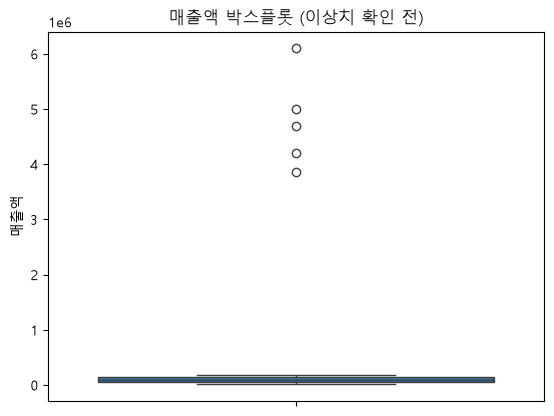

수량 이상치 (오입력 의심):
         주문일자   지점 카테고리       매출액  수량         요일
48 2024-03-10  강남점  스포츠  157695.0  95     Sunday
74 2024-01-17  잠실점   패션   72037.0  95  Wednesday
이상치 제거 후 최종 데이터 개수: 193


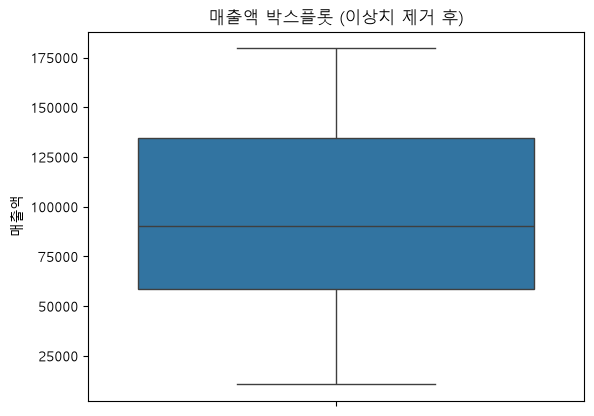

In [30]:
df["수량"] = df["수량"].astype(int)

Q1 = df["매출액"].quantile(0.25)
Q3 = df["매출액"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"매출액 정상 범위: {lower_bound:.0f} ~ {upper_bound:.0f}")

price_outliers = df[(df["매출액"] < lower_bound) | (df["매출액"] > upper_bound)]
print("매출액 이상치:")
print(price_outliers)

sns.boxplot(data=df, y="매출액")
plt.title("매출액 박스플롯 (이상치 확인 전)")
plt.show()

qty_outliers = df[df["수량"] > 20]
print("수량 이상치 (오입력 의심):")
print(qty_outliers)

df = df[(df["매출액"] >= lower_bound) & (df["매출액"] <= upper_bound)]
df = df[df["수량"] <= 20]

print(f"이상치 제거 후 최종 데이터 개수: {len(df)}")

sns.boxplot(data=df, y="매출액")
plt.title("매출액 박스플롯 (이상치 제거 후)")
plt.show()

In [34]:
print(df.describe())

branch_sales = df.groupby("지점")["매출액"].sum().sort_values(ascending=False)
print(branch_sales)

category_sales = df.groupby("카테고리")["매출액"].sum().sort_values(ascending=False)
print(category_sales)

cross_analysis = df.groupby(["지점", "카테고리"])["매출액"].sum().reset_index()
print(cross_analysis)

                             주문일자            매출액          수량
count                         193     193.000000  193.000000
mean   2024-02-15 18:24:14.922279   95444.132124    3.445596
min           2024-01-01 00:00:00   10661.000000    1.000000
25%           2024-01-22 00:00:00   58627.000000    2.000000
50%           2024-02-19 00:00:00   90291.000000    3.000000
75%           2024-03-10 00:00:00  134745.000000    5.000000
max           2024-03-30 00:00:00  179627.000000    6.000000
std                           NaN   46931.577271    1.638849
지점
부산점    4300271.0
본점     3908820.0
잠실점    3594291.0
강남점    3199208.0
대구점    3175423.5
미상      242704.0
Name: 매출액, dtype: float64
카테고리
스포츠    3614188.5
식품     3507577.0
뷰티     3194833.0
패션     2909870.0
도서     2707798.0
가전     2486451.0
Name: 매출액, dtype: float64
     지점 카테고리        매출액
0   강남점   가전   206065.0
1   강남점   도서   218987.0
2   강남점   뷰티   505606.0
3   강남점  스포츠  1042300.0
4   강남점   식품   810202.0
5   강남점   패션   416048.0
6   대구점   가전   3968

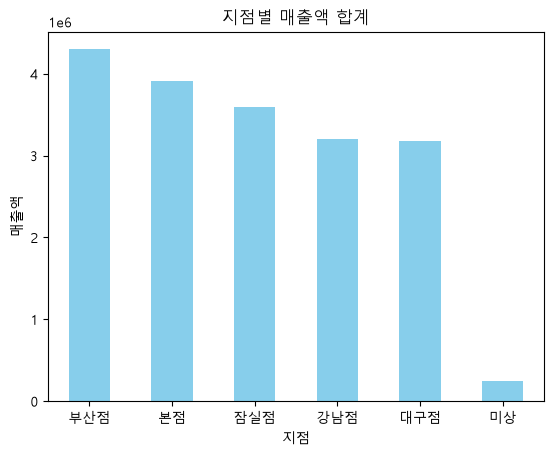

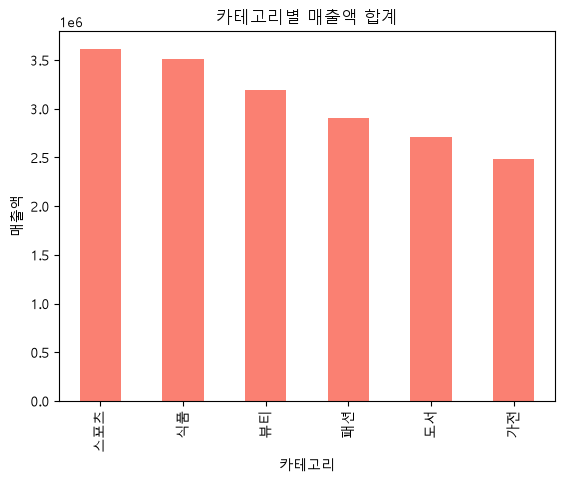

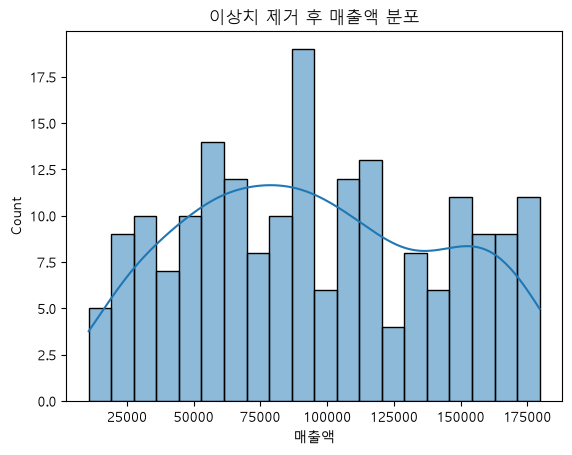

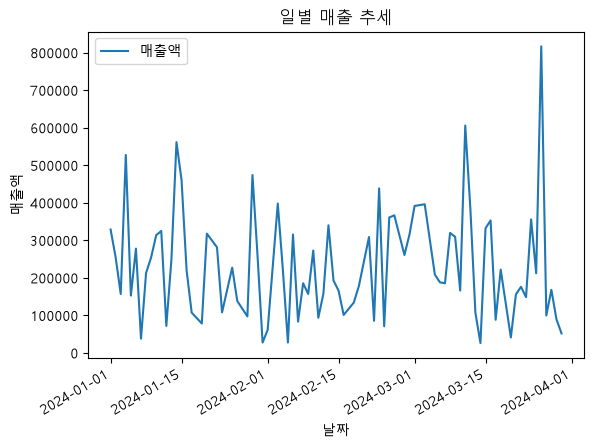

In [39]:
branch_sales.plot(kind="bar", color="skyblue")
plt.title("지점별 매출액 합계")
plt.ylabel("매출액")
plt.xticks(rotation=0)
plt.show()

category_sales.plot(kind="bar", color="salmon")
plt.title("카테고리별 매출액 합계")
plt.ylabel("매출액")
plt.show()

sns.histplot(data=df, x="매출액", bins=20, kde=True)
plt.title("이상치 제거 후 매출액 분포")
plt.show()

daily_sales = df.groupby("주문일자")["매출액"].sum().reset_index()
daily_sales.plot(kind="line", x="주문일자", y="매출액")
plt.title("일별 매출 추세")
plt.xlabel("날짜")
plt.ylabel("매출액")
plt.show()

In [44]:
best_branch = branch_sales.idxmax()
best_category = category_sales.idxmax()

print(f"매출이 가장 높은 지점: {best_branch}")
print(f"매출이 가장 높은 카테고리: {best_category}")

매출이 가장 높은 지점: 부산점
매출이 가장 높은 카테고리: 스포츠
